# Feature count and memote score

Runs across all 10 models in `02_final_annotated/` (unlike notebooks 03+, this one doesn't
exclude `iBsu1103`/`iBsu1103v2`/`iBsu1209` - it's a pre-filtering QC pass).

In [ ]:
import os
from cobra.io import read_sbml_model
import pandas as pd
from openpyxl import Workbook
from memote.suite.api import test_model
from memote.suite.api import snapshot_report

# Counts genes/metabolites/reactions in a model
def get_genes_met_rx(model):
    n_genes = len(model.genes)
    n_metabolites = len(model.metabolites)
    n_reactions = len(model.reactions)
    return n_genes, n_metabolites, n_reactions

# Runs MEMOTE on a model, saves its HTML report to reports_dir, returns the total score (%)
def generate_report(model, model_name, reports_dir):
    try:
        print(f"[INFO] Memote for {model_name} (model.id={model.id!r})")
        model.solver = "gurobi"

        code, result_dict = test_model(model, results=True, solver_timeout=10)
        html_report = snapshot_report(result_dict, html=True)
        # model_name (from the source filename), not model.id: several models here share
        # the same model.id (empty, or duplicate mergem ids), which would overwrite reports.
        report_path = os.path.join(reports_dir, f"{model_name}_memote_report.html")
        with open(report_path, "w", encoding="utf-8") as f:
            f.write(html_report)

        score = result_dict["score"]["total_score"]
        score = score * 100
        return score
    except Exception as e:
        print(f"[ERROR] Memote test failed for {model_name}: {e}")
        return None

# Gets the biomass reaction ID from the model's objective function
def  get_biomass_reaction(model):
    biomass_obj = str(model.objective)
    biomass_id = biomass_obj.split('*')[1].split()[0]

    return biomass_id  

 # Molecular weight of the biomass pseudometabolite
def calculate_biomass_mol_weight(model, biomass_id):

    rxn = model.reactions.get_by_id(biomass_id)

    total_mw = 0.0
    skipped = False
    rows = []

    for met, coef in rxn.metabolites.items():

        try:
            fw = met.formula_weight or 0.0
        except:
            fw = 0.0
            skipped = True

        if fw == 0.0:
            skipped = True

        contribution = -coef * fw
        total_mw += contribution

        rows.append({
            "metabolite": met.id,
            "coefficient": coef,
            "formula_weight": fw,
            "contribution": contribution
        })

    contribution_df = pd.DataFrame(rows)

    return total_mw / 1000.0, skipped, contribution_df


For each model: count genes/metabolites/reactions, run MEMOTE, and compute the biomass reaction's molecular weight. Results are written to an Excel summary.

In [ ]:
import os
import pandas as pd
from cobra.io import read_sbml_model


folder_path = os.path.join(os.getcwd(), "..", "data", "models", "02_final_annotated")
reports_dir = os.path.join(os.getcwd(), "..", "results", "reports")
os.makedirs(reports_dir, exist_ok=True)

COLUMNS = ["Model", "Genes", "Metabolites", "Reactions", "Score", "Biomass ID", "Bx MW",
           "Missing metabolites?", "Biomass contributions"]
rows = []

for file in os.listdir(folder_path):
    if file.endswith(".xml"):
        model_name = file.replace(".xml", "")
        file_path = os.path.join(folder_path, file)
        
        try:
            model = read_sbml_model(file_path)
            n_genes, n_metabolites, n_reactions = get_genes_met_rx(model)
            score = generate_report(model, model_name, reports_dir)
            biomass_id = get_biomass_reaction(model)
            bx_mw, missing, contributions_str = calculate_biomass_mol_weight(model, biomass_id)
            
            rows.append([model_name, n_genes, n_metabolites, n_reactions, score, biomass_id, bx_mw, missing, str(contributions_str)])
            
        except Exception as e:
            print(f"[ERROR] Failed to process {file}: {e}")

output_path = os.path.join(os.getcwd(), "..", "results", "tables", "Score.csv")
pd.DataFrame(rows, columns=COLUMNS).to_csv(output_path, index=False)
print(f"\n[FINISHED] Summary table successfully saved to: {output_path}")

## Load results

In [13]:
import os
import pandas as pd
folder_path = os.path.join(os.getcwd(), "..", "data", "models", "02_final_annotated")
output_path = os.path.join(os.getcwd(), "..", "results", "tables", "Score.csv")
df = pd.read_csv(output_path)
df

,Model,Genes,Metabolites,Reactions,Score,Biomass ID,Bx MW,Missing metabolites?,Biomass contributions
0,iYO844,844,990,1250,82.484398,BIOMASS_BS_10,1.040130,True,metabolite coefficient formula_weight co...
1,iBsu1103,1109,1625,1925,73.856152,bio00006,0.000000,True,metabolite coefficient formula_weight c...
2,iBsu1103v2,1108,1639,1948,60.137126,bio00127,0.000000,True,metabolite coefficient formula_weight c...
3,iBsu1147,1147,1456,1742,59.818953,bio00006,0.154818,True,metabolite coefficient formula_weight ...
4,eciYO844,861,1009,1267,56.399054,BIOMASS_BS_10,0.000000,True,metabolite coefficient formula_weight co...
5,iBsu1209,1209,1582,1950,47.880235,bio00006,0.132476,True,metabolite coefficient formula_weight ...
6,iBB1018,1020,1291,1580,64.719564,BiomassRepsolRed,0.155000,True,metabolite coefficient formula_weigh...
7,iBsu1147R,1155,1459,1736,58.507479,bio00006,0.048984,True,metabolite coefficient formula_weight ...
8,ecBSU1,1155,1459,3307,54.018034,bio00006,0.048984,True,metabolite coefficient formula_weight ...
9,Submodel,2364,1810,2188,61.135073,BIOMASS_BS_10,1.042819,False,metabolite coefficient formula_weight co...


Plots feature count and memote score:

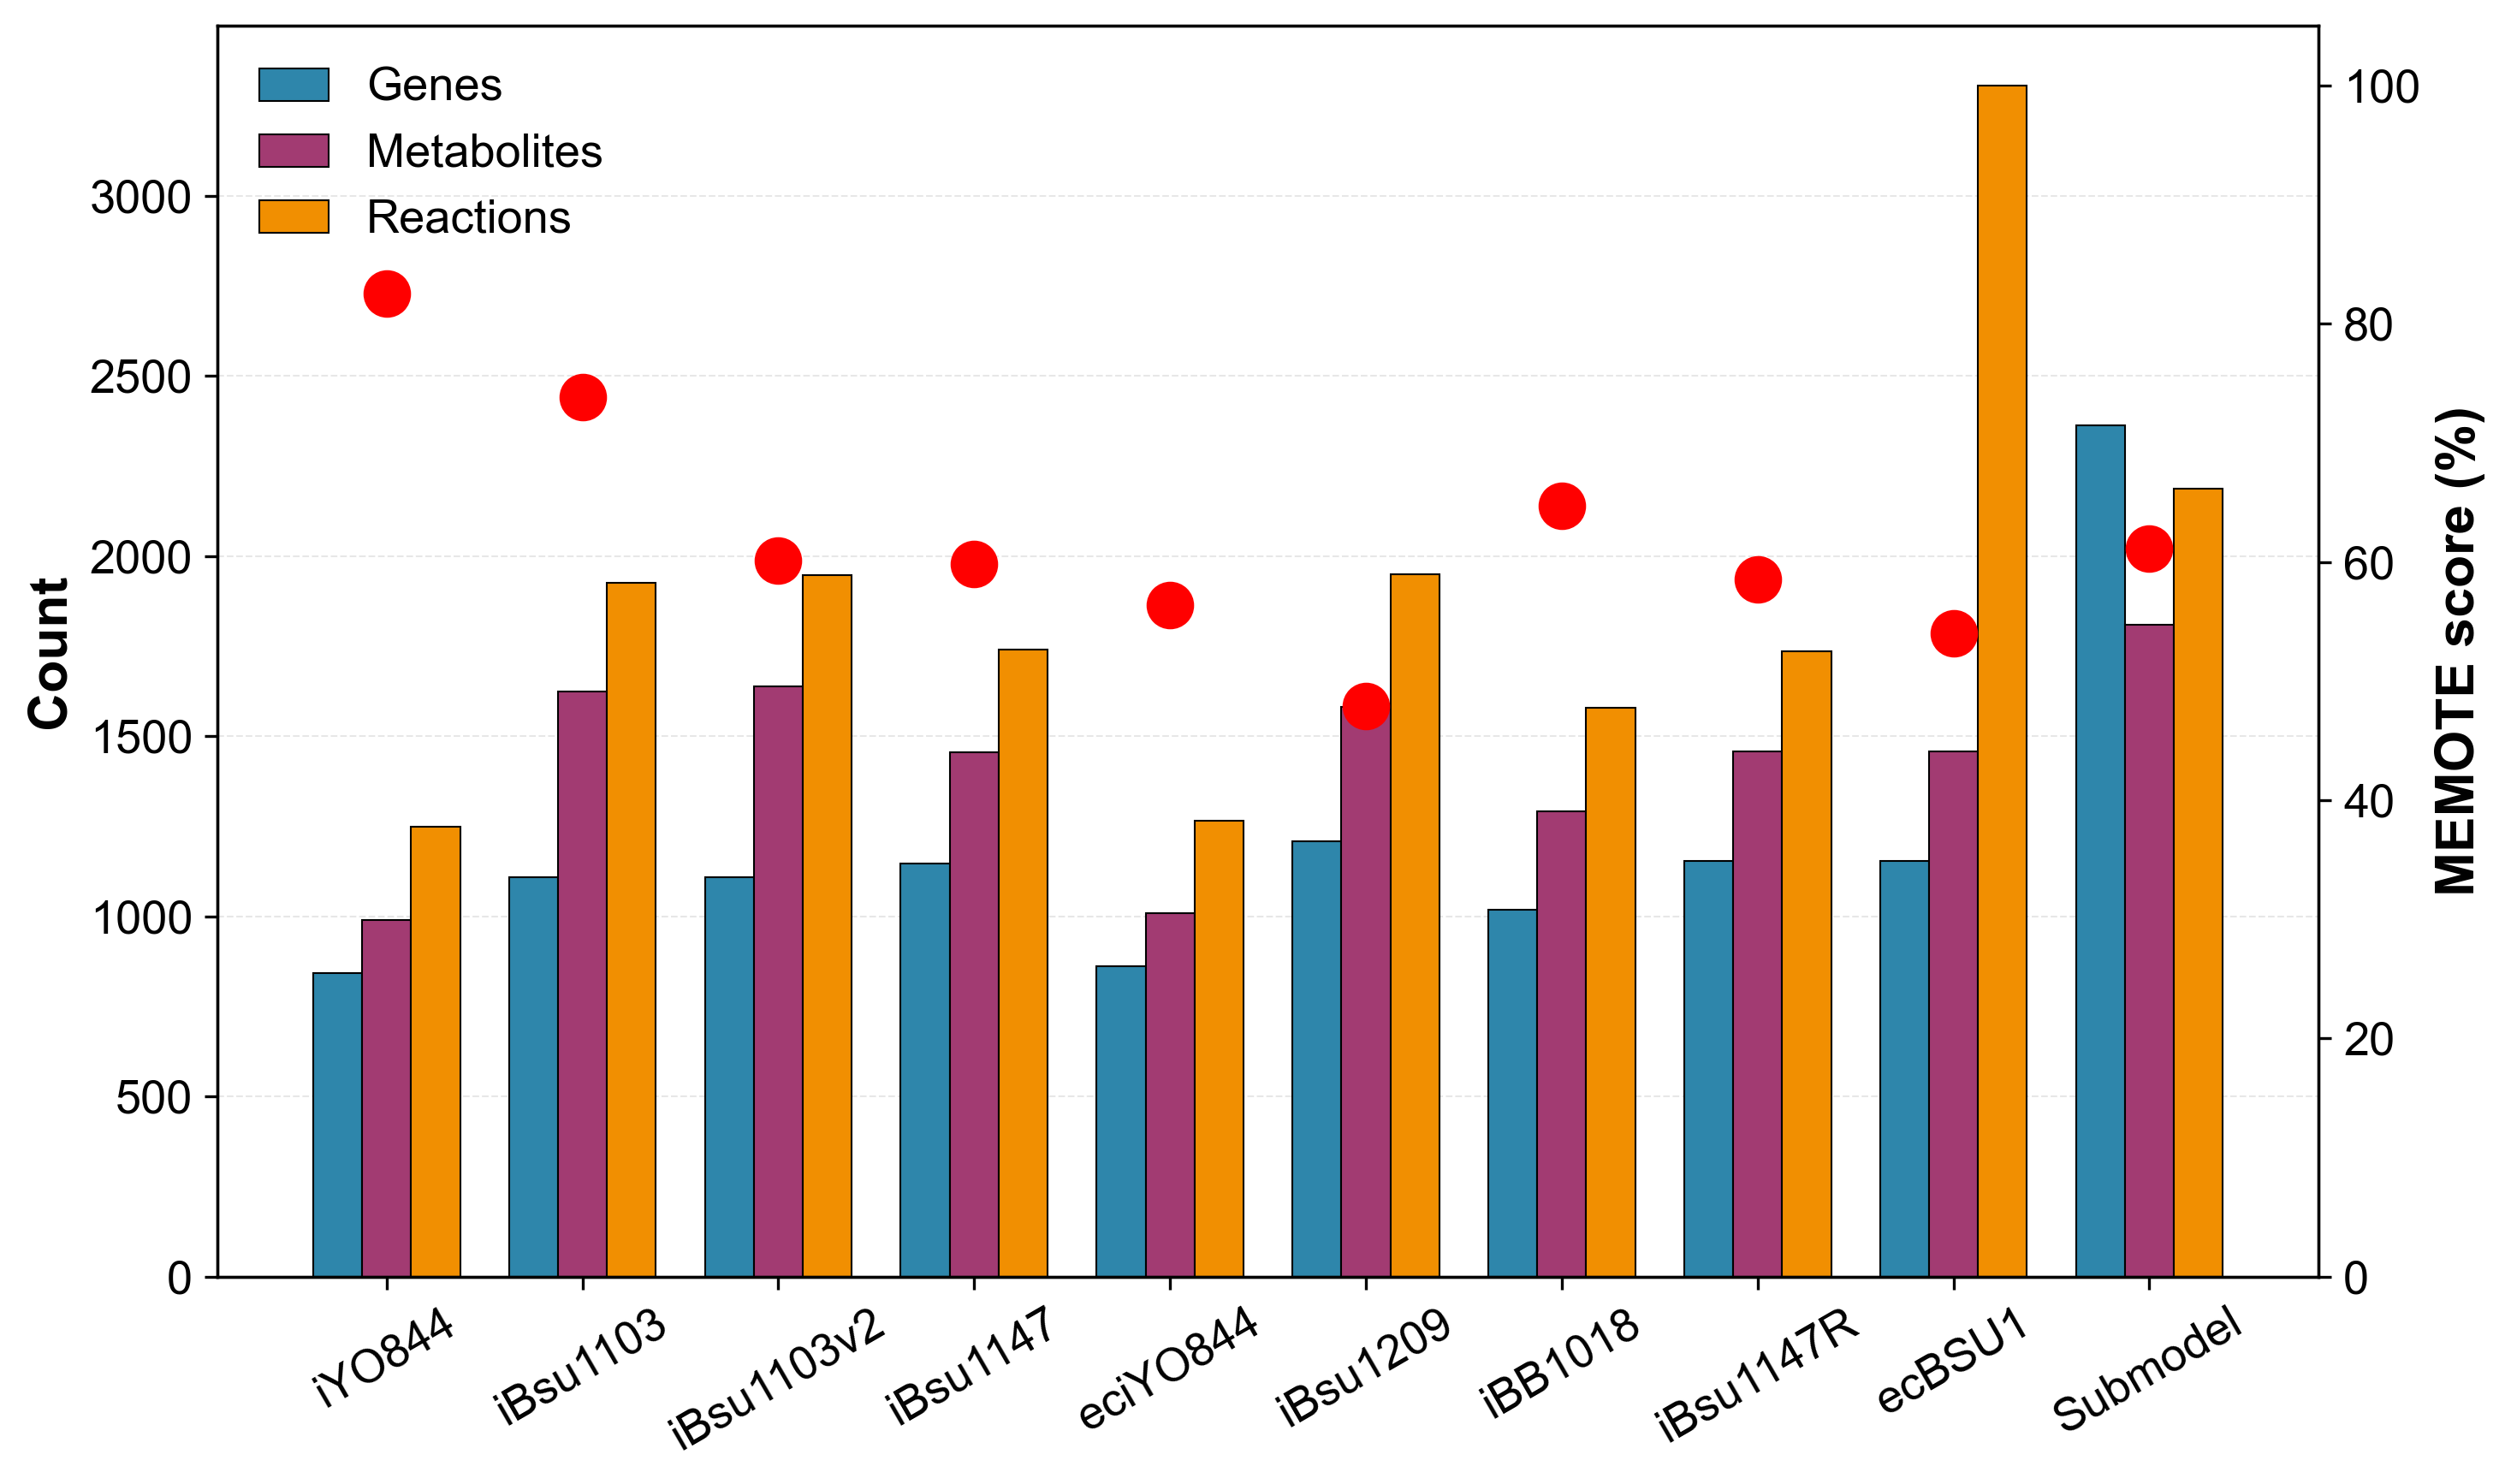


[FINISHED] Figure successfully saved to: c:\Users\felip\Desktop\python\Bacillus_GEMs_Paper copy\analysis\notebooks\..\results\figures\Feature count and score after SBOannotation.pdf


In [16]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'], 
    # Math in labels ($\mu$, h$^{-1}$) otherwise renders in matplotlib's default DejaVu while
    # the surrounding text is Arial, so one axis label ends up in two typefaces.
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
    'font.size': 14,
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'figure.dpi': 300,
    'savefig.dpi': 800,
    'figure.figsize': (10, 6),
    'axes.linewidth': 0.8,
    'lines.linewidth': 1.5,
    'grid.alpha': 0.3
})

models = df["Model"]
genes = df["Genes"]
metabolites = df["Metabolites"]
reactions = df["Reactions"]
scores = df["Score"]

x = np.arange(len(models))
width = 0.25

fig, ax1 = plt.subplots()

bars1 = ax1.bar(x - width, genes, width, label="Genes", 
                color='#2E86AB', edgecolor='black', linewidth=0.5)
bars2 = ax1.bar(x, metabolites, width, label="Metabolites", 
                color='#A23B72', edgecolor='black', linewidth=0.5)
bars3 = ax1.bar(x + width, reactions, width, label="Reactions", 
                color='#F18F01', edgecolor='black', linewidth=0.5)

ax1.set_ylabel("Count", fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=30, ha='center')

ax1.grid(axis='y', linestyle='--', alpha=0.3, linewidth=0.5)
ax1.set_axisbelow(True)  
ax2 = ax1.twinx()
x_clean = []
scores_clean = []

for i, score in enumerate(scores):
    try:
        scores_clean.append(float(score))
        x_clean.append(x[i])
    except (ValueError, TypeError):
        print(f"Skipping '{models[i]}': score '{score}' non float")


scatter = ax2.scatter(x_clean, scores_clean,
            color='red',
            s=140,
            edgecolors='red',
            linewidth=1.5,
            zorder=5)

ax2.set_ylabel("MEMOTE score (%)", fontweight='bold')
ax2.set_ylim(0, 105) 
ax2.set_yticks(np.arange(0, 110, 20))

ax1.legend(loc='upper left', 
           frameon=False,         
           fontsize=13,
           handlelength=1.5)


plt.tight_layout()
output_path = os.path.join(os.getcwd(), "..", "results", "figures")
output_img_path = os.path.join(output_path, "Feature count and score after SBOannotation.pdf")
plt.savefig(output_img_path, dpi=800, bbox_inches="tight")
plt.show()
print(f"\n[FINISHED] Figure successfully saved to: {output_img_path}")